## Carga y Tratamiento Inicial de Audios

### Estructura de los datasets

**NeuroVoz** 
- 2976 archivos de múltiples tareas: vocales, palabras, frases, habla espontánea, PATAKA...
- Formato: {HC|PD}_{TIPO}_{ID_PACIENTE}.wav
- Solo nos interesan: {HC|PD}_{VOCAL}{N}_{ID}.wav → ej. HC_A1_0034.wav, PD_E2_0011.wav

**PC-GITA**
- Ya organizado por carpetas de vocal → menos limpieza necesaria
- Formato: AVPEPUDEA{C|P}{NNNN}{vocal}{rep}.wav → ej. AVPEPUDEAC0001a1.wav


In [38]:
import os
import re
import shutil
import numpy as np
import pandas as pd
import soundfile as sf
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('✅ Imports OK')

✅ Imports OK


In [ ]:
######### RUTAS #########

BASE_DIR = Path(os.getcwd()).parent.parent   # raíz del proyecto
DATA_DIR = BASE_DIR / 'data'

NEUROVOZ_AUDIO_DIR = DATA_DIR / 'neurovoz' / 'audios'
PCGITA_DIR         = DATA_DIR / 'pc-gita'

# Carpeta donde guardaremos los CSVs de metadatos limpios
PROCESSED_DIR = DATA_DIR / 'processed'
# PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f'BASE_DIR  : {BASE_DIR}')
print(f'DATA_DIR  : {DATA_DIR}')
print(f'NEUROVOZ  : {NEUROVOZ_AUDIO_DIR.exists()}')
print(f'PC-GITA   : {PCGITA_DIR.exists()}')
# print(f'PROCESSED : {PROCESSED_DIR}')

BASE_DIR  : c:\Users\julia\LOCAL_JULIA\PROYECTOS GIT\TFM DATA SCIENCE\TFM-Data-Science
DATA_DIR  : c:\Users\julia\LOCAL_JULIA\PROYECTOS GIT\TFM DATA SCIENCE\TFM-Data-Science\data
NEUROVOZ  : True
PC-GITA   : True
PROCESSED : c:\Users\julia\LOCAL_JULIA\PROYECTOS GIT\TFM DATA SCIENCE\TFM-Data-Science\data\processed


In [40]:
######### CONFIGURACIÓN #########

VOCALES_INTERES = ['A', 'E', 'I', 'O', 'U']

# Repeticiones a incluir de NeuroVoz (1 y 2; la 3 existe solo para pocos pacientes)
REPETICIONES_NV = [1, 2]

# Repeticiones de PC-GITA (siempre tiene 3)
REPETICIONES_PG = [1, 2, 3]

### 1. NEUROVOZ — Exploración, filtrado y organización en carpetas

- Escaneamos todos los archivos `.wav`
- Filtramos los archivos .wav para quedarnos solo con vocales sostenidas (A, E, I, O, U)
- Copiamos los archivos válidos a carpetas organizadas por HC/PD → vocal
- Verificamos que ningún paciente aparece en ambos grupos
- Mostramos un gráfico con la distribución de audios conservados

In [ ]:
####### PATRÓN PARA IDENTIFICAR VOCALES SOSTENIDAS ##########
# Filtramos para quedarnos solo con los audios de vocales sostenidas,  y eliminar los que son palabras, frases ...

VOCAL_PATTERN_NV = re.compile(r'^(HC|PD)_([AEIOUaeiou])(\d+)_(\d+)$')

def parse_neurovoz_filename(filepath):
    m = VOCAL_PATTERN_NV.match(filepath.stem)
    if m:
        return {
            'filepath':   str(filepath),
            'dataset':    'neurovoz',
            'label':      m.group(1),
            'vocal':      m.group(2).upper(),
            'repeticion': int(m.group(3)),
            'patient_id': m.group(4),
        }
    return None


######## ESCANEO Y FILTRADO INICIAL #########

all_nv_files = sorted(NEUROVOZ_AUDIO_DIR.glob('*.wav'))

NEUROVOZ_ORGANIZADO_DIR = DATA_DIR / 'Org_Neurovoz'
records = []

# n_descartado = 0

for wav in all_nv_files:
    info = parse_neurovoz_filename(wav)
    if info is None or info['vocal'] not in VOCALES_INTERES or info['repeticion'] not in REPETICIONES_NV:
        # n_descartado += 1
        continue
    records.append(info)


# ------ TABLA RESUMEN : pacientes y repeticiones por vocal -------
print(f"\n{'Grupo':<8} {'Vocal':<8} {'Pacientes':>10} {'Solo rep1':>10} {'Solo rep2':>10} {'Ambas reps':>11}")
print('─' * 60)

for label in ['HC', 'PD']:
    for vocal in VOCALES_INTERES:
        sub = df_nv[(df_nv['label'] == label) & (df_nv['vocal'] == vocal)]
        if sub.empty:
            continue

        reps_por_pac = sub.groupby('patient_id')['repeticion'].apply(set)
        n_pacientes  = len(reps_por_pac)
        solo_rep1    = (reps_por_pac == {1}).sum()
        solo_rep2    = (reps_por_pac == {2}).sum()
        ambas        = (reps_por_pac == {1, 2}).sum()

        print(f'{label:<8} {vocal:<8} {n_pacientes:>10} {solo_rep1:>10} {solo_rep2:>10} {ambas:>11}')
    print()

df_nv_raw = pd.DataFrame(records)



########## FILTRAR SOLO PACIENTES CON DOS REPETICIONES ########
# Contamos cuántas repeticiones tiene cada paciente para cada vocal
reps_por_paciente = df_nv_raw.groupby(['label', 'vocal', 'patient_id'])['repeticion'].count()
pacientes_completos = reps_por_paciente[reps_por_paciente == len(REPETICIONES_NV)].reset_index()[['label', 'vocal', 'patient_id']]

# Nos quedamos solo con los registros de esos pacientes
df_nv = df_nv_raw.merge(pacientes_completos, on=['label', 'vocal', 'patient_id'])



# ########## COPIAMOS A CARPETA ORG NEUROVOZ  ##########
if NEUROVOZ_ORGANIZADO_DIR.exists():
    shutil.rmtree(NEUROVOZ_ORGANIZADO_DIR)
    print(f'\n Carpeta anterior eliminada')

for _, row in df_nv.iterrows():
    dest_folder = NEUROVOZ_ORGANIZADO_DIR / row['label'] / row['vocal']
    dest_folder.mkdir(parents=True, exist_ok=True)
    shutil.copy2(row['filepath'], dest_folder / Path(row['filepath']).name)


########### VERIFICACIÓN DE PACIENTES ENTRE GRUPOS SANOS/ENFERMOS ##########
pacientes_hc = set(df_nv[df_nv['label'] == 'HC']['patient_id'])
pacientes_pd = set(df_nv[df_nv['label'] == 'PD']['patient_id'])
interseccion = pacientes_hc & pacientes_pd

if len(interseccion) == 0:
    print('\nNingún paciente está catalogado como HC y PD a la vez.')
else:
    print(f'\n¡ALERTA! Pacientes en ambos grupos: {interseccion}')



########### GRÁFICO: distribución definitiva ###########
counts = df_nv.groupby(['vocal', 'label']).size().unstack(fill_value=0)

x = np.arange(len(counts.index))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 6))

bars_hc = ax.bar(x - w/2, counts.get('HC', 0), w, label='HC (Sano)',     color='#42A5F5', edgecolor='white', alpha=0.9)
bars_pd = ax.bar(x + w/2, counts.get('PD', 0), w, label='PD (Parkinson)', color='#EF5350', edgecolor='white', alpha=0.9)

for bar in list(bars_hc) + list(bars_pd):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, str(int(h)),
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(counts.index, fontsize=12)
ax.set_xlabel('Vocal', fontsize=12)
ax.set_ylabel('Nº audios', fontsize=12)
ax.set_title('NeuroVoz', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'DATAD_DIR' is not defined

### ANALISIS DE PC GITA

In [ ]:
# ─── PC-GITA — Inventario directo desde carpetas ──────────────────────────────
# La estructura ya está organizada: pc-gita / {Control|Patologicas} / {Vocal} /
print(f"{'Grupo':<15} {'Vocal':<8} {'Nº audios':>10} {'Nº pacientes':>13}")
print('─' * 50)

for grupo in ['Control', 'Patologicas']:
    grupo_dir = PCGITA_DIR / grupo
    if not grupo_dir.exists():
        print(f'No existe la carpeta: {grupo_dir}')
        continue

    for vocal in sorted(v.name for v in grupo_dir.iterdir() if v.is_dir()):
        vocal_dir = grupo_dir / vocal
        wavs = sorted(vocal_dir.glob('*.wav'))
        
        # El ID del paciente son las 4 cifras que aparecen en el nombre del fichero
        ids_unicos = set(re.search(r'\d{4}', w.stem).group() for w in wavs if re.search(r'\d{4}', w.stem))
        
        print(f'{grupo:<15} {vocal:<8} {len(wavs):>10} {len(ids_unicos):>13}')


Grupo           Vocal     Nº audios  Nº pacientes
──────────────────────────────────────────────────
Control         A               150            50
Control         E               150            50
Control         I               150            50
Control         O               150            50
Control         U               150            50
Patologicas     A               150            50
Patologicas     E               150            50
Patologicas     I               150            50
Patologicas     O               150            50
Patologicas     U               150            50



### 3. Pacientes únicos — cuántos hay en cada dataset

In [ ]:
for ds_name, df in [('NeuroVoz', df_nv), ('PC-GITA', df_pg)]:
    print(f'\n=== {ds_name} ===')
    for vocal in VOCALES_INTERES:
        sub = df[df['vocal'] == vocal]
        if sub.empty:
            continue
        n_pac_hc = sub[sub['label']=='HC']['patient_id'].nunique()
        n_pac_pd = sub[sub['label']=='PD']['patient_id'].nunique()
        print(f'  Vocal {vocal}: {sub["patient_id"].nunique()} pacientes únicos '
              f'(HC={n_pac_hc}, PD={n_pac_pd}) — {len(sub)} audios totales')

NameError: name 'df_pg' is not defined

### 4. Cálculo de duraciones

Leemos la duración de cada archivo leyendo solo la cabecera WAV  
(sin cargar el audio completo en RAM).

In [ ]:
def get_duration(filepath):
    """Duración en segundos leyendo la cabecera del WAV sin cargar el audio."""
    try:
        info = sf.info(filepath)
        return info.frames / info.samplerate
    except Exception as e:
        print(f'ERROR: {Path(filepath).name} — {e}')
        return None

print('Calculando duraciones NeuroVoz...', end=' ')
df_nv['duration_s'] = df_nv['filepath'].apply(get_duration)
print(f'OK  ({df_nv["duration_s"].isna().sum()} errores)')

print('Calculando duraciones PC-GITA...', end='  ')
df_pg['duration_s'] = df_pg['filepath'].apply(get_duration)
print(f'OK  ({df_pg["duration_s"].isna().sum()} errores)')

# Eliminamos filas con error de lectura
df_nv = df_nv.dropna(subset=['duration_s']).reset_index(drop=True)
df_pg = df_pg.dropna(subset=['duration_s']).reset_index(drop=True)

print('\n✅ Duraciones calculadas')

Calculando duraciones NeuroVoz... OK  (0 errores)
Calculando duraciones PC-GITA...  OK  (0 errores)

✅ Duraciones calculadas


### 5. Análisis de duraciones — estadísticas

In [ ]:
for ds_name, df in [('NeuroVoz', df_nv), ('PC-GITA', df_pg)]:
    print(f'\n{"═"*55}')
    print(f'{ds_name} — Duración (segundos) por vocal')
    print('═'*55)
    stats = (df.groupby('vocal')['duration_s']
               .agg(['min', 'max', 'mean', 'median', 'std', 'count'])
               .rename(columns={'min':'mín','max':'máx',
                                'mean':'media','median':'mediana',
                                'std':'desv.std','count':'n'}))
    print(stats.round(3).to_string())


═══════════════════════════════════════════════════════
NeuroVoz — Duración (segundos) por vocal
═══════════════════════════════════════════════════════
         mín     máx  media  mediana  desv.std    n
vocal                                              
A      0.533   9.889  3.804    3.652     1.156  214
E      0.908   8.426  4.177    3.972     1.305  134
I      1.388  11.878  4.332    4.123     1.301  198
O      1.482  10.735  4.254    4.105     1.212  198
U      1.389  10.779  4.357    4.055     1.901   56

═══════════════════════════════════════════════════════
PC-GITA — Duración (segundos) por vocal
═══════════════════════════════════════════════════════
         mín     máx  media  mediana  desv.std    n
vocal                                              
A      0.489  20.222  2.998    2.304     2.519  300
E      0.575  16.417  2.862    2.378     2.182  300
I      0.546  24.793  2.845    2.124     2.508  300
O      0.440  15.905  2.566    1.948     2.048  300
U      0.368  15.

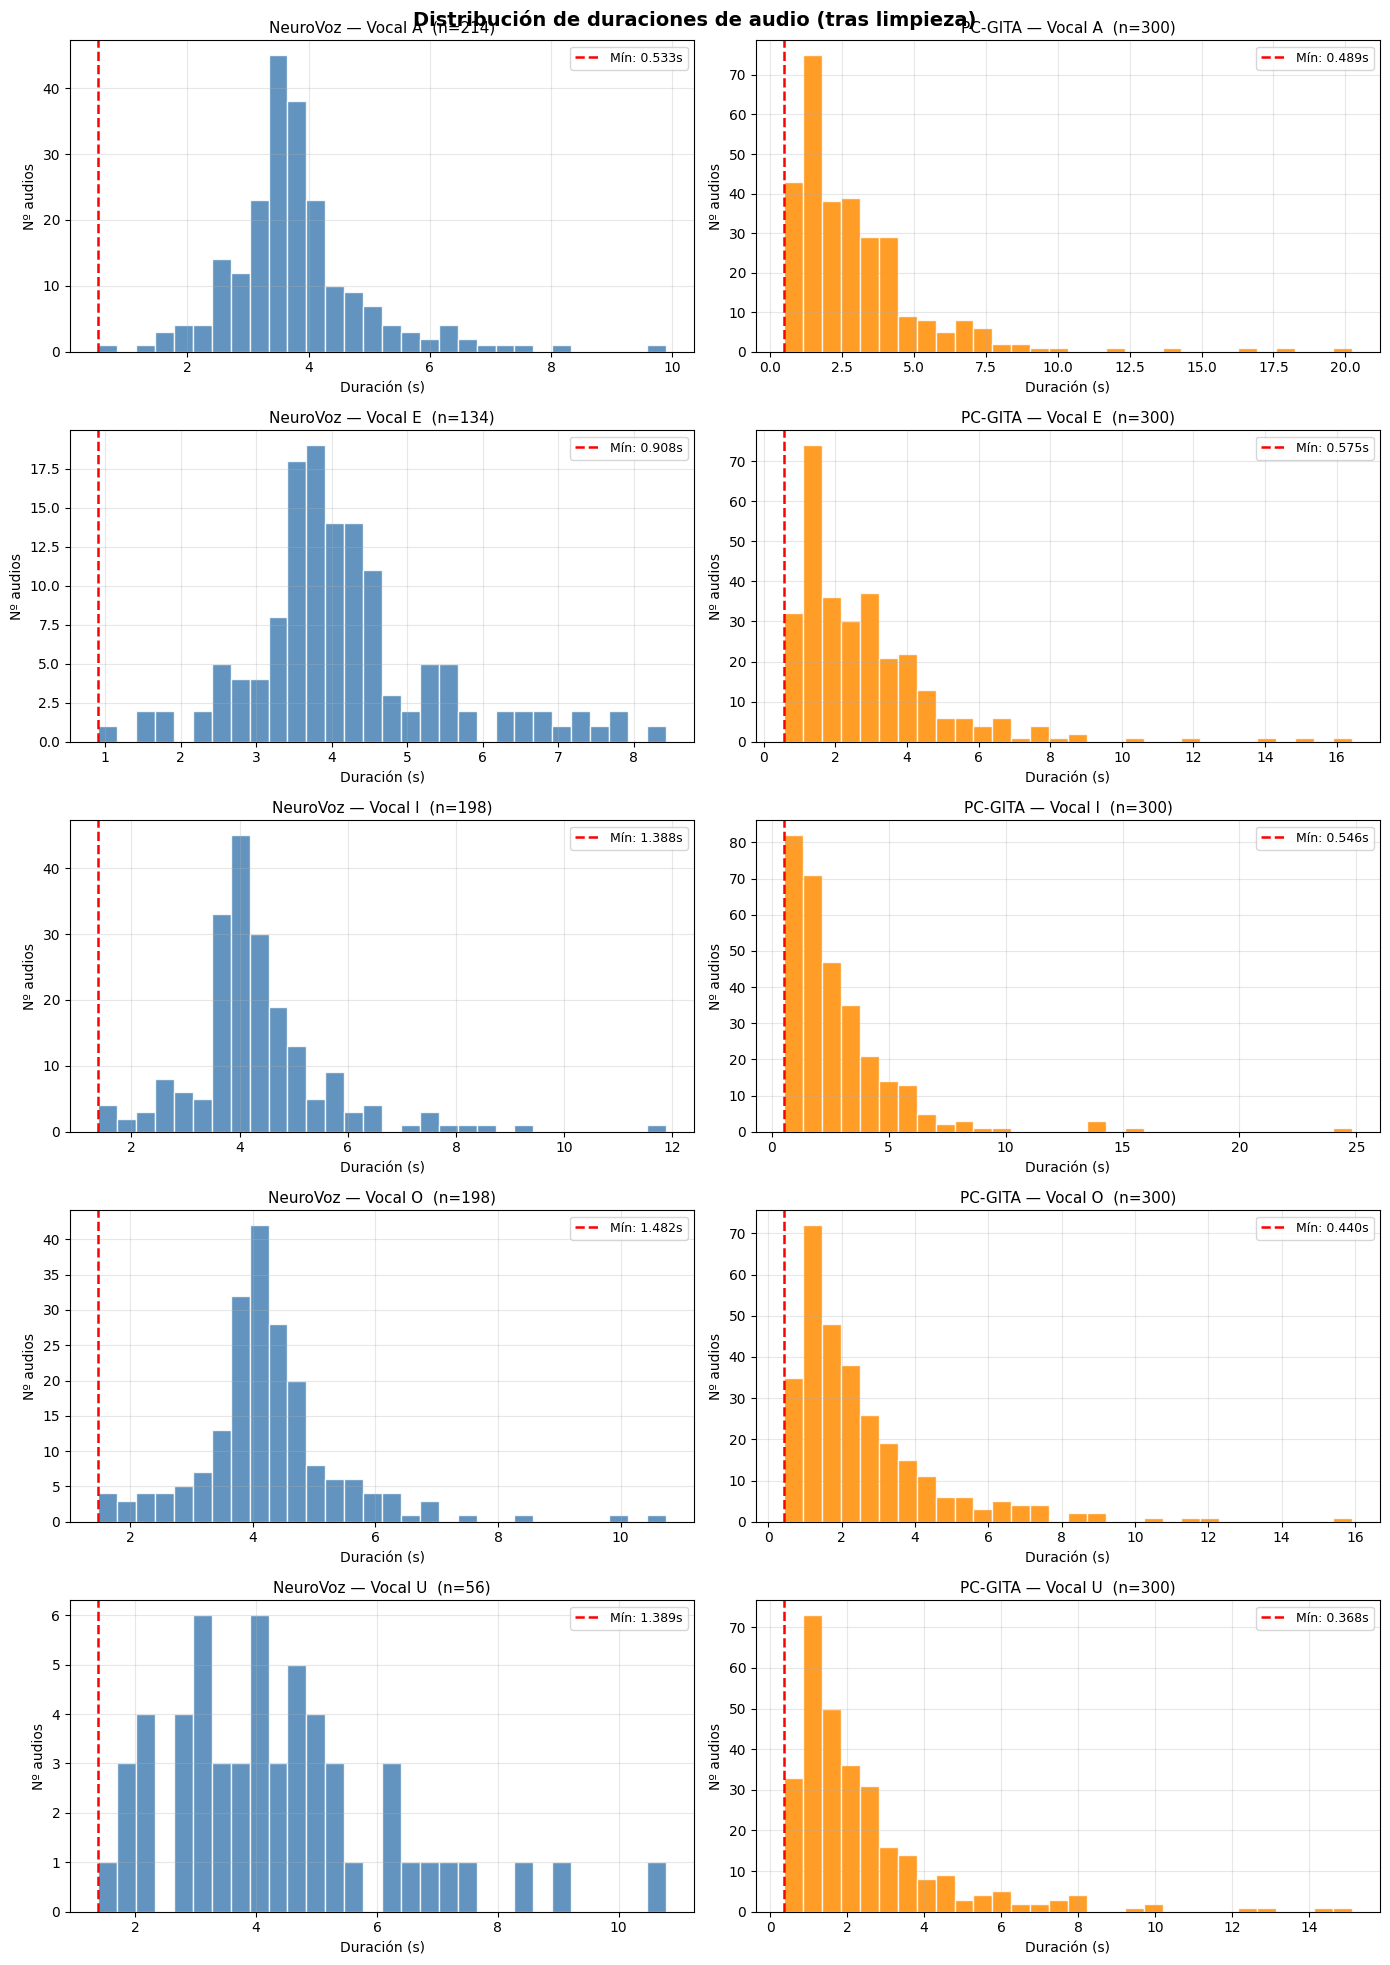

In [ ]:
# ─── HISTOGRAMAS DE DURACIÓN ──────────────────────────────────────────────────
n_vocales = len(VOCALES_INTERES)
fig, axes = plt.subplots(n_vocales, 2, figsize=(14, 4 * n_vocales))
fig.suptitle('Distribución de duraciones de audio (tras limpieza)', fontsize=14, fontweight='bold')

datasets_plot = [
    (df_nv, 'NeuroVoz', 'steelblue'),
    (df_pg, 'PC-GITA',  'darkorange'),
]

for col, (df, ds_name, color) in enumerate(datasets_plot):
    for row, vocal in enumerate(VOCALES_INTERES):
        ax = axes[row][col]
        data = df[df['vocal'] == vocal]['duration_s']
        if data.empty:
            ax.set_visible(False)
            continue
        ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
        min_v = data.min()
        ax.axvline(min_v, color='red', linestyle='--', lw=1.8,
                   label=f'Mín: {min_v:.3f}s')
        ax.set_title(f'{ds_name} — Vocal {vocal}  (n={len(data)})', fontsize=11)
        ax.set_xlabel('Duración (s)')
        ax.set_ylabel('Nº audios')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Detección de audios potencialmente defectuosos

Identificamos los audios más cortos de cada grupo.  
Un audio muy corto puede ser una grabación fallida o un silencio.

In [ ]:
N_SHORTEST = 10   # cuántos audios cortos mostrar por grupo

for ds_name, df in [('NeuroVoz', df_nv), ('PC-GITA', df_pg)]:
    print(f'\n{"═"*65}')
    print(f'{ds_name} — {N_SHORTEST} audios más cortos por vocal')
    print('═'*65)
    for vocal in VOCALES_INTERES:
        sub = df[df['vocal'] == vocal]
        if sub.empty:
            continue
        sub = sub.nsmallest(N_SHORTEST, 'duration_s')
        print(f'\n  Vocal {vocal}:')
        for _, row in sub.iterrows():
            fname = Path(row['filepath']).name
            flag  = '  ⚠️' if row['duration_s'] < 0.5 else ''
            print(f'    {row["label"]} | pac {row["patient_id"]} | '
                  f'rep {row["repeticion"]} | {row["duration_s"]:.3f}s  '
                  f'{fname}{flag}')


═════════════════════════════════════════════════════════════════
NeuroVoz — 10 audios más cortos por vocal
═════════════════════════════════════════════════════════════════

  Vocal A:
    HC | pac 0056 | rep 2 | 0.533s  HC_A2_0056.wav
    HC | pac 0132 | rep 2 | 1.457s  HC_A2_0132.wav
    HC | pac 0130 | rep 2 | 1.479s  HC_A2_0130.wav
    PD | pac 0016 | rep 1 | 1.567s  PD_A1_0016.wav
    HC | pac 0138 | rep 2 | 1.719s  HC_A2_0138.wav
    HC | pac 0140 | rep 2 | 1.821s  HC_A2_0140.wav
    PD | pac 0016 | rep 2 | 1.873s  PD_A2_0016.wav
    PD | pac 0004 | rep 1 | 1.995s  PD_A1_0004.wav
    HC | pac 0132 | rep 1 | 2.056s  HC_A1_0132.wav
    HC | pac 0135 | rep 2 | 2.193s  HC_A2_0135.wav

  Vocal E:
    HC | pac 0132 | rep 1 | 0.908s  HC_E1_0132.wav
    HC | pac 0130 | rep 2 | 1.623s  HC_E2_0130.wav
    HC | pac 0132 | rep 2 | 1.640s  HC_E2_0132.wav
    PD | pac 0109 | rep 1 | 1.743s  PD_E1_0109.wav
    HC | pac 0141 | rep 2 | 1.752s  HC_E2_0141.wav
    HC | pac 0140 | rep 2 | 2.186s  

In [ ]:
# ─── DURACIÓN MÍNIMA POR DATASET Y VOCAL ─────────────────────────────────────
# Este será el valor de recorte que aplicaremos en el siguiente notebook
print(f"{'Dataset':<12} {'Vocal':<8} {'Mín (s)':>9} {'Mín (ms)':>10}")
print('-' * 42)

min_durations = {}
for ds_key, df in [('neurovoz', df_nv), ('pcgita', df_pg)]:
    for vocal in VOCALES_INTERES:
        sub = df[df['vocal'] == vocal]
        if sub.empty:
            continue
        min_d = sub['duration_s'].min()
        min_durations[f'{ds_key}_{vocal}'] = min_d
        print(f'{ds_key:<12} {vocal:<8} {min_d:>9.4f} {min_d*1000:>10.1f}')

print()
print('💡 Estos valores se usarán en el notebook de preprocesamiento para recortar todos los audios.')

Dataset      Vocal      Mín (s)   Mín (ms)
------------------------------------------
neurovoz     A           0.5333      533.3
neurovoz     E           0.9079      907.9
neurovoz     I           1.3878     1387.8
neurovoz     O           1.4819     1481.9
neurovoz     U           1.3886     1388.6
pcgita       A           0.4889      488.9
pcgita       E           0.5749      574.9
pcgita       I           0.5458      545.8
pcgita       O           0.4397      439.7
pcgita       U           0.3682      368.2

💡 Estos valores se usarán en el notebook de preprocesamiento para recortar todos los audios.


### 7. Guardado de metadatos limpios

Exportamos un CSV por dataset con toda la información necesaria:
- Ruta al archivo de audio
- Dataset, label (HC/PD), vocal, repetición, patient_id
- Duración real del audio

Estos CSVs serán el punto de entrada del notebook de división train/val/test y del de extracción de features.

In [ ]:
# Añadimos columna con la duración de recorte que le corresponde a cada audio
# (= la duración mínima del grupo vocal × dataset)
df_nv['crop_duration_s'] = df_nv['vocal'].map(
    {v: min_durations[f'neurovoz_{v}'] for v in VOCALES_INTERES if f'neurovoz_{v}' in min_durations}
)
df_pg['crop_duration_s'] = df_pg['vocal'].map(
    {v: min_durations[f'pcgita_{v}'] for v in VOCALES_INTERES if f'pcgita_{v}' in min_durations}
)

# Guardamos
nv_out = PROCESSED_DIR / 'neurovoz_vocales.csv'
pg_out = PROCESSED_DIR / 'pcgita_vocales.csv'

df_nv.to_csv(nv_out, index=False)
df_pg.to_csv(pg_out, index=False)

print(f'✅ {nv_out.name}  ({len(df_nv)} filas)')
print(f'✅ {pg_out.name}  ({len(df_pg)} filas)')
print(f'\nColumnas: {list(df_nv.columns)}')

✅ neurovoz_vocales.csv  (800 filas)
✅ pcgita_vocales.csv  (1500 filas)

Columnas: ['filepath', 'dataset', 'label', 'vocal', 'repeticion', 'patient_id', 'duration_s', 'crop_duration_s']


In [ ]:
# Guardamos también las duraciones mínimas por separado
min_dur_df = pd.DataFrame([
    {
        'dataset':         k.split('_')[0],
        'vocal':           k.split('_')[1].upper(),
        'min_duration_s':  round(v, 6),
        'min_duration_ms': round(v * 1000, 1)
    }
    for k, v in min_durations.items()
])
min_dur_out = PROCESSED_DIR / 'min_durations.csv'
min_dur_df.to_csv(min_dur_out, index=False)

print(f'✅ {min_dur_out.name}')
print()
print(min_dur_df.to_string(index=False))

✅ min_durations.csv

 dataset vocal  min_duration_s  min_duration_ms
neurovoz     A        0.533265            533.3
neurovoz     E        0.907868            907.9
neurovoz     I        1.387800           1387.8
neurovoz     O        1.481905           1481.9
neurovoz     U        1.388639           1388.6
  pcgita     A        0.488912            488.9
  pcgita     E        0.574921            574.9
  pcgita     I        0.545805            545.8
  pcgita     O        0.439705            439.7
  pcgita     U        0.368231            368.2


### 8. Resumen final

In [ ]:
print('=' * 65)
print('RESUMEN FINAL')
print('=' * 65)

print(f'\n📂 NeuroVoz — {len(all_nv_files)} archivos en disco')
print(f'   ❌ Descartados (palabras/frases/otros o vocal no deseada) : {n_no_vocal}')
print(f'   ✅ Conservados en este análisis                           : {len(df_nv)}')

for ds_name, df, ds_key in [('NeuroVoz', df_nv, 'neurovoz'), ('PC-GITA', df_pg, 'pcgita')]:
    print(f'\n▶ {ds_name}')
    for vocal in VOCALES_INTERES:
        sub = df[df['vocal'] == vocal]
        if sub.empty:
            continue
        key = f'{ds_key}_{vocal}'
        min_d = min_durations.get(key, float('nan'))
        n_hc  = (sub['label']=='HC').sum()
        n_pd  = (sub['label']=='PD').sum()
        n_pac = sub['patient_id'].nunique()
        print(f'  Vocal {vocal}:')
        print(f'    Audios totales  : {len(sub)}  (HC={n_hc}, PD={n_pd})')
        print(f'    Pacientes únicos: {n_pac}')
        print(f'    Duración mínima : {min_d:.4f}s  ({min_d*1000:.1f}ms)')
        print(f'    Duración máxima : {sub["duration_s"].max():.4f}s')
        print(f'    Duración media  : {sub["duration_s"].mean():.4f}s')

print(f'\n\n📁 CSVs guardados en: {PROCESSED_DIR}')
for f in sorted(PROCESSED_DIR.glob('*.csv')):
    print(f'   → {f.name}')

print()
print('🔜 Siguiente paso: notebook de división train/val/test (agrupado por paciente)')

RESUMEN FINAL

📂 NeuroVoz — 2976 archivos en disco
   ❌ Descartados (palabras/frases/otros o vocal no deseada) : 1910
   ✅ Conservados en este análisis                           : 800

▶ NeuroVoz
  Vocal A:
    Audios totales  : 214  (HC=110, PD=104)
    Pacientes únicos: 107
    Duración mínima : 0.5333s  (533.3ms)
    Duración máxima : 9.8895s
    Duración media  : 3.8037s
  Vocal E:
    Audios totales  : 134  (HC=46, PD=88)
    Pacientes únicos: 67
    Duración mínima : 0.9079s  (907.9ms)
    Duración máxima : 8.4258s
    Duración media  : 4.1765s
  Vocal I:
    Audios totales  : 198  (HC=94, PD=104)
    Pacientes únicos: 99
    Duración mínima : 1.3878s  (1387.8ms)
    Duración máxima : 11.8783s
    Duración media  : 4.3323s
  Vocal O:
    Audios totales  : 198  (HC=110, PD=88)
    Pacientes únicos: 99
    Duración mínima : 1.4819s  (1481.9ms)
    Duración máxima : 10.7349s
    Duración media  : 4.2544s
  Vocal U:
    Audios totales  : 56  (HC=46, PD=10)
    Pacientes únicos: 28
  